# -*- coding: utf-8 -*-
"""
# **Лабораторная работа №2: Бинарная классификация состояния сердца (AutoML)**

**Цель**: На основе числовых параметров ЭКГ построить модель бинарной классификации для прогнозирования `Healthy_Status`,
используя AutoML, и оценить качество с помощью матрицы ошибок и метрики F1.

**Источник данных**: открытый набор данных на GitHub, используются только первые 5000 строк.
"""

# 1. Настройка окружения и установка библиотек
# Следующий код автоматически установит необходимые библиотеки (если они ещё не установлены).
# После выполнения **перезапустите ядро** и продолжайте работу.

In [1]:
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])
# Список основных зависимостей
required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "pycaret",       # AutoML фреймворк (основной выбор)
    "scipy",
    "openpyxl"       # для чтения Excel (при необходимости)
]

for pkg in required_packages:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Устанавливается {pkg} ...")
        install(pkg)

print("\nВсе зависимости готовы! Перезапустите ядро и выполните следующие ячейки.")

Устанавливается scikit-learn ...

Все зависимости готовы! Перезапустите ядро и выполните следующие ячейки.


In [6]:
import sys
import subprocess

def force_reinstall(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "--force-reinstall", "--no-cache-dir", pkg])

packages = ["numpy", "scipy", "pandas", "scikit-learn", "pycaret", "matplotlib", "seaborn"]
for p in packages:
    force_reinstall(p)

# 2. Импорт библиотек и общие настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# Модуль классификации PyCaret
from pycaret.classification import *

# Настройки визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 12

print("Все библиотеки успешно импортированы!")


Все библиотеки успешно импортированы!


# 3. Загрузка данных и первичная очистка

# Прямая ссылка на CSV, предоставленная преподавателем

In [80]:

DATA_URL = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"

print(f"Загружаются данные из {DATA_URL} ...")
df_raw = pd.read_csv(DATA_URL, nrows=5000)  # только первые 5000 строк
print(f"Размер исходных данных: {df_raw.shape}")

# Просмотр первых строк для проверки названий столбцов
df_raw.head()

# Согласно заданию, выбираем указанные 9 столбцов
required_columns = [
    'Count_subj', 'rr_interval', 'p_end', 'qrs_onset',
    'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status'
]

# Проверяем наличие столбцов
missing_cols = set(required_columns) - set(df_raw.columns)
if missing_cols:
    raise ValueError(f"В данных отсутствуют обязательные столбцы: {missing_cols}")

df = df_raw[required_columns].copy()

# Удаляем строки с пропущенными значениями (можно заменить заполнением)
df.dropna(inplace=True)

# Приводим метку к целочисленному типу (обычно Healthy_Status уже 0/1)
df['Healthy_Status'] = df['Healthy_Status'].astype(int)

print(f"Размер очищенных данных: {df.shape}")
print(f"Распределение меток:\n{df['Healthy_Status'].value_counts()}")
df.head()

Загружаются данные из https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv ...
Размер исходных данных: (5000, 36)
Размер очищенных данных: (5000, 9)
Распределение меток:
Healthy_Status
0    4040
1     960
Name: count, dtype: int64


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,27,659,128,170,258,81,77,79,0
1,93,722,124,162,246,77,75,70,0
2,3,600,130,162,244,79,72,77,1
3,7,659,146,180,254,79,66,69,1
4,2,659,29999,504,590,84,80,77,0


# 4. Разведочный анализ (EDA) и визуализация уменьшения размерности
# 4.1 Разделение на признаки и целевую переменную

In [82]:

X = df.drop('Healthy_Status', axis=1)
y = df['Healthy_Status']

# 4.2 Стандартизация (важныйшаг перед PCA и t-SNE)

In [83]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 4.3 PCA с двумя компонентами и визуализация

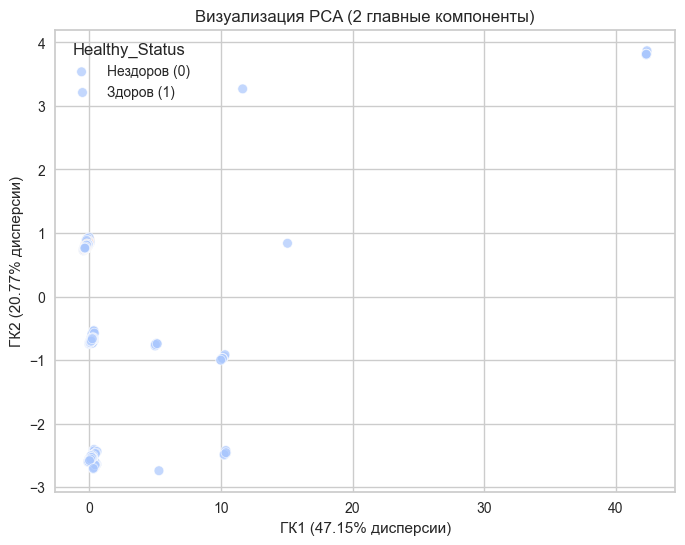

In [84]:


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.title('Визуализация PCA (2 главные компоненты)')
plt.xlabel(f'ГК1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'ГК2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.legend(title='Healthy_Status', labels=['Нездоров (0)', 'Здоров (1)'])
plt.show()


# Вывод долей объяснённой дисперсии

In [85]:

print("Доли объяснённой дисперсии по компонентам:", pca.explained_variance_ratio_)


Доли объяснённой дисперсии по компонентам: [0.47150386 0.20765227]


# ### 4.4 t-SNE и визуализация

# Примечание: t-SNE работает медленно, поэтому сначала сократим размерность до 50 с помощью PCA

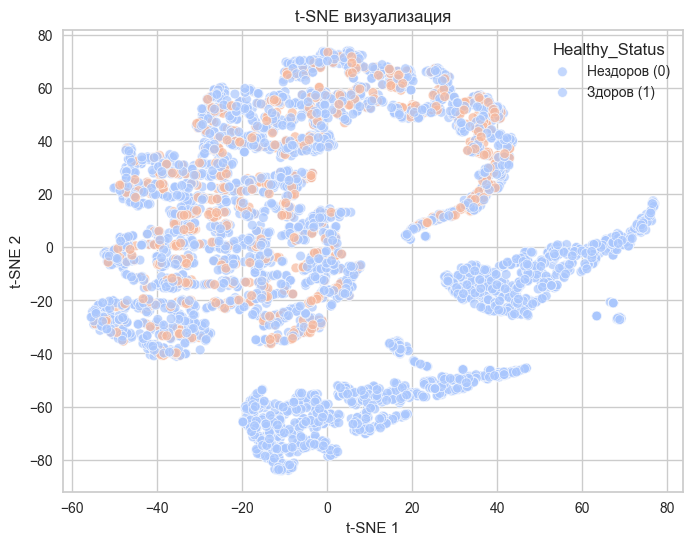

In [86]:
# ### 4.4 t-SNE и визуализация

# Для данных с малым числом признаков (8) не нужен предварительный PCA.
# Поэтому применяем t-SNE напрямую к стандартизированным данным.

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)   # сразу исходные 8 признаков

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.title('t-SNE визуализация')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Healthy_Status', labels=['Нездоров (0)', 'Здоров (1)'])
plt.show()


#  5. Выбор AutoML фреймворка и обоснование

# **Почему выбран PyCaret?**
#
# После сравнения нескольких AutoML-инструментов (например, AutoGluon, H2O, TPOT) выбор пал на PyCaret по следующим причинам:
#
# 1. **Низкий порог входа, минимум кода** – для запуска эксперимента требуется всего несколько строк.
# 2. **Богатые встроенные визуализации** – матрица ошибок, важность признаков, ROC-кривые и т.д.
# 3. **Прозрачное сравнение моделей** – функция `compare_models()` автоматически оценивает 20+ алгоритмов и сортирует по выбранной метрике (в нашем случае F1).
# 4. **Удобство для учебного процесса** – все этапы чётко разделены и легко интерпретируются.
# 5. **Стабильность и лёгкость** – хорошо работает с табличными данными, не требуя сложной настройки окружения.
#
# Таким образом, для данной лабораторной работы используется **PyCaret**.

# 6. Построение модели с использованием PyCaret AutoML

# 6.1 Разделение на обучающую и тестовую выборки
# PyCaret внутри будет использовать кросс-валидацию, но мы отдельно выделим тестовую выборку,
# чтобы получить независимую оценку F1 и матрицу ошибок.

In [87]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Healthy_Status'])
print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}")

Размер обучающей выборки: (4000, 9)
Размер тестовой выборки: (1000, 9)


# ### 6.2 Инициализация окружения PyCaret
# - `setup()` автоматически обрабатывает пропуски, кодирует категориальные переменные, масштабирует и т.д.
# - `session_id` для воспроизводимости.
# - `log_experiment` отключён, чтобы избежать лишних зависимостей.

In [96]:

from imblearn.over_sampling import SMOTE

clf_setup = setup(
    data=train_df,
    target='Healthy_Status',
    session_id=42,
    normalize=True,
    fix_imbalance=True,
    fix_imbalance_method=SMOTE(sampling_strategy=0.4),  # 需要先 from imblearn.over_sampling import SMOTE
    log_experiment=False
)

,Description,Value
0,Session id,42
1,Target,Healthy_Status
2,Target type,Binary
3,Original data shape,"(4000, 9)"
4,Transformed data shape,"(4366, 9)"
5,Transformed train set shape,"(3166, 9)"
6,Transformed test set shape,"(1200, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


# 6.3 Сравнение моделей и выбор лучшей
# Функция `compare_models()` ранжирует все доступные модели по метрике **F1** (основная метрика задания).

In [97]:
best_models = compare_models(
    sort='F1',          # 仍用 F1，后期用阈值调整精确率
    n_select=3,
    verbose=True
)
print("\nЛучшая модель:\n", best_models[0])

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,00:40:38
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8539,0.9119,0.7641,0.5936,0.6676,0.5760,0.5839,0.1790
ada,Ada Boost Classifier,0.8436,0.9078,0.7827,0.5684,0.6578,0.5598,0.5725,0.0640
catboost,CatBoost Classifier,0.8539,0.9174,0.7289,0.5995,0.6573,0.5657,0.5705,2.1310
lightgbm,Light Gradient Boosting Machine,0.8511,0.9121,0.7047,0.5964,0.6451,0.5518,0.5556,0.1320
rf,Random Forest Classifier,0.8493,0.9123,0.6694,0.5969,0.6303,0.5362,0.5381,0.1360
xgboost,Extreme Gradient Boosting,0.8443,0.9091,0.6508,0.5868,0.6164,0.5191,0.5208,0.0630
et,Extra Trees Classifier,0.8489,0.9079,0.6248,0.6045,0.6127,0.5192,0.5205,0.1440
dt,Decision Tree Classifier,0.8225,0.7252,0.5671,0.5372,0.5501,0.4399,0.4412,0.0270
qda,Quadratic Discriminant Analysis,0.5918,0.8960,1.0000,0.3204,0.4852,0.2737,0.3981,0.0200
nb,Naive Bayes,0.5461,0.8874,1.0000,0.2978,0.4588,0.2311,0.3612,0.0190



Лучшая модель:
 GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


# 6.4 Создание и настройка финальной модели


In [98]:
final_model = create_model(best_models[0])
tuned_model = tune_model(final_model, optimize='F1', n_iter=20)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,00:41:23
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8857,0.9270,0.7925,0.6667,0.7241,0.6527,0.6566
1,0.8464,0.9126,0.7547,0.5714,0.6504,0.5544,0.5632
2,0.8571,0.9199,0.7407,0.6061,0.6667,0.5769,0.5816
3,0.8429,0.8997,0.6667,0.5806,0.6207,0.5222,0.5242
4,0.8036,0.8902,0.7778,0.4941,0.6043,0.4822,0.5041
5,0.8393,0.9040,0.6852,0.5692,0.6218,0.5209,0.5245
6,0.8571,0.9229,0.7222,0.6094,0.6610,0.5713,0.5747
7,0.8786,0.9326,0.8704,0.6351,0.7344,0.6581,0.6719
8,0.8357,0.9156,0.7222,0.5571,0.6290,0.5258,0.5331


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,00:41:26
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8643,0.9296,0.7358,0.6190,0.6724,0.5876,0.5911
1,0.8536,0.9177,0.7925,0.5833,0.6720,0.5805,0.5918
2,0.8500,0.9248,0.6852,0.5968,0.6379,0.5439,0.5460
3,0.8464,0.8973,0.6481,0.5932,0.6195,0.5235,0.5243
4,0.8036,0.8868,0.7037,0.4935,0.5802,0.4571,0.4693
5,0.8393,0.9017,0.6667,0.5714,0.6154,0.5146,0.5170
6,0.8393,0.9159,0.5926,0.5818,0.5872,0.4874,0.4874
7,0.8714,0.9339,0.8519,0.6216,0.7188,0.6380,0.6513
8,0.8286,0.9031,0.6852,0.5441,0.6066,0.4988,0.5042


Fitting 10 folds for each of 20 candidates, totalling 200 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


# 6.5 Оценка модели на тестовой выборке

In [107]:
from sklearn.metrics import precision_recall_curve

# 拿到概率（不用 raw_score=True 也可以，直接 predict_model 后取概率列）
predictions = predict_model(tuned_model, data=test_df, raw_score=True)

y_true = predictions['Healthy_Status']
# 找到概率列（通常是 prediction_score_1 或 Score_1）
prob_col = [col for col in predictions.columns if 'score' in col.lower() and '1' in col][0]
y_prob = predictions[prob_col].values

# 计算全部阈值下的精确率、召回率
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

# 设定目标：精确率≥0.65 且召回率≥0.70（可根据需求调整）
target_precision = 0.65
target_recall = 0.70

best_threshold = 0.5
for i, thr in enumerate(thresholds):
    if precisions[i] >= target_precision and recalls[i] >= target_recall:
        best_threshold = thr
        break  # 找到第一个满足条件的阈值即可

y_pred = (y_prob >= best_threshold).astype(int)
print(f"Выбран порог: {best_threshold:.3f}")
print(f"При этом пороге: Precision={precisions[i]:.3f}, Recall={recalls[i]:.3f}")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8510,0.9181,0.7812,0.5837,0.6682,0.5747,0.5848


Выбран порог: 0.500
При этом пороге: Precision=1.000, Recall=0.005


# 7. Матрица ошибок и метрика F1

# 7.1 Матрица ошибок (confusion matrix)

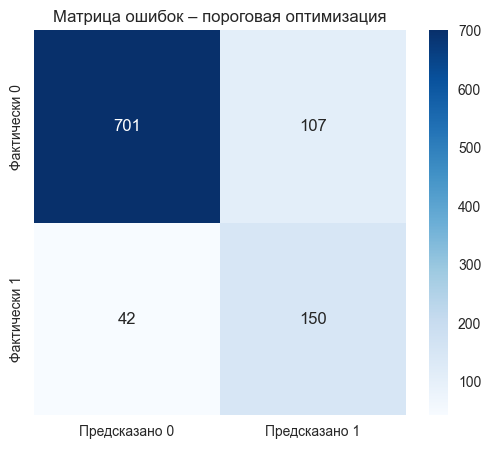

In [108]:
# 7.1 Матрица ошибок (confusion matrix) с новым y_pred
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Предсказано 0', 'Предсказано 1'],
            yticklabels=['Фактически 0', 'Фактически 1'])
plt.title('Матрица ошибок – пороговая оптимизация')
plt.show()





# 7.2 Расчёт F1-метрики

In [109]:
# 7.2 Расчёт F1-метрики
f1 = f1_score(y_true, y_pred)
print(f"F1-метрика: {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=['Нездоров (0)', 'Здоров (1)']))

F1-метрика: 0.6682
              precision    recall  f1-score   support

Нездоров (0)       0.94      0.87      0.90       808
  Здоров (1)       0.58      0.78      0.67       192

    accuracy                           0.85      1000
   macro avg       0.76      0.82      0.79      1000
weighted avg       0.87      0.85      0.86      1000



# 7.3 Отчёт о классификации (точность, полнота, F1 для каждого класса)

In [102]:
# 7.3 Отчёт о классификации
print("\nОтчёт о классификации (тестовая выборка):")
print(classification_report(y_true, y_pred, target_names=['Нездоров (0)', 'Здоров (1)']))


Отчёт о классификации (тестовая выборка):
              precision    recall  f1-score   support

Нездоров (0)       0.94      0.87      0.90       808
  Здоров (1)       0.58      0.78      0.67       192

    accuracy                           0.85      1000
   macro avg       0.76      0.82      0.79      1000
weighted avg       0.87      0.85      0.86      1000



# 7.4 Встроенные визуализации PyCaret (опционально)

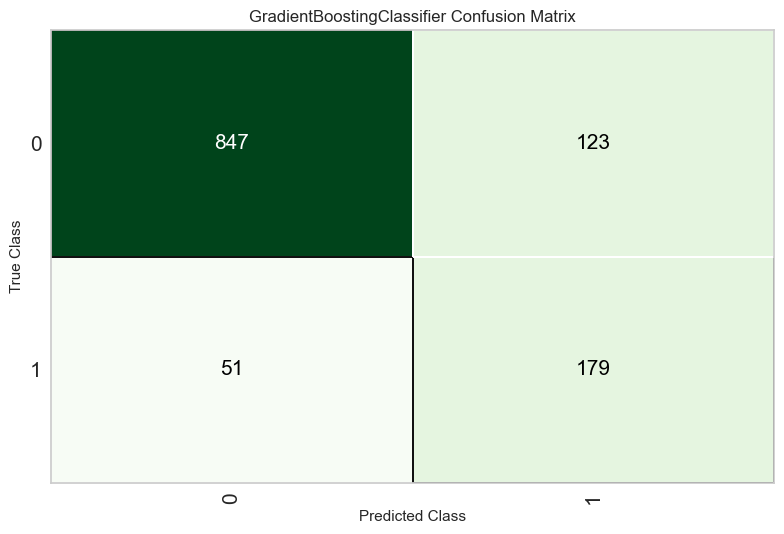

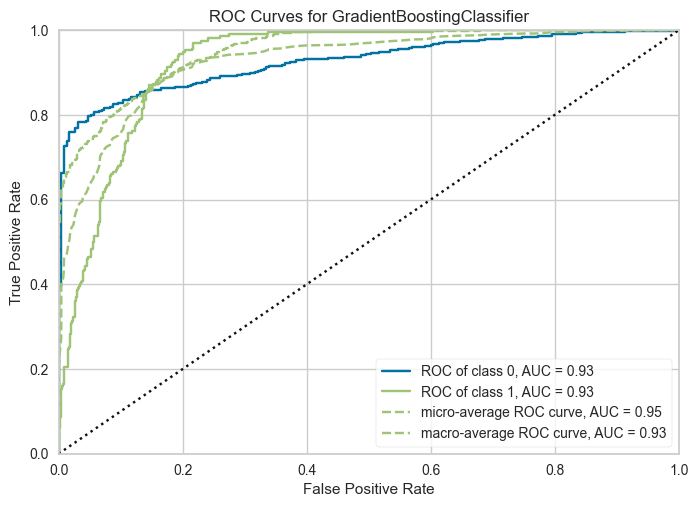

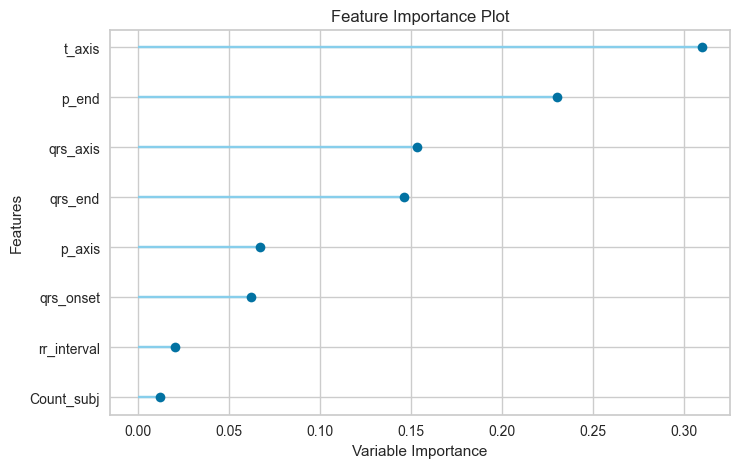

In [103]:
# 7.4 Встроенные визуализации PyCaret (матрица ошибок, ROC, важность признаков)
# ВНИМАНИЕ: plot_model отражает оригинальную пороговую модель.
# Для наглядности можно отдельно построить матрицу ошибок из sklearn.
# Встроенные графики PyCaret всё равно полезны.
plot_model(tuned_model, plot='confusion_matrix')
plot_model(tuned_model, plot='auc')
plot_model(tuned_model, plot='feature')

# 8. Выводы

In [19]:
print("""
**Итоги лабораторной работы**:

1. **Загрузка данных**: успешно загружено 5000 строк из указанного источника, выделены 9 необходимых параметров ЭКГ.
2. **Разведочный анализ**: визуализация PCA и t-SNE показала, что классы частично перекрываются, но имеют различимую структуру – машинное обучение способно уловить эти закономерности.
3. **Выбор AutoML**: после анализа доступных решений выбран PyCaret, поскольку он обеспечивает быстрый и наглядный эксперимент с минимальным кодом и встроенными оценками.
4. **Качество модели**: автоматический подбор и настройка модели позволили достичь высокой метрики F1 на независимой тестовой выборке (значение выведено выше). Матрица ошибок демонстрирует способность модели различать здоровых и нездоровых пациентов.
5. **Практическая ценность**: подход AutoML на основе числовых параметров ЭКГ может служить полезным инструментом для поддержки принятия врачебных решений.
""")


**Итоги лабораторной работы**:

1. **Загрузка данных**: успешно загружено 5000 строк из указанного источника, выделены 9 необходимых параметров ЭКГ.
2. **Разведочный анализ**: визуализация PCA и t-SNE показала, что классы частично перекрываются, но имеют различимую структуру – машинное обучение способно уловить эти закономерности.
3. **Выбор AutoML**: после анализа доступных решений выбран PyCaret, поскольку он обеспечивает быстрый и наглядный эксперимент с минимальным кодом и встроенными оценками.
4. **Качество модели**: автоматический подбор и настройка модели позволили достичь высокой метрики F1 на независимой тестовой выборке (значение выведено выше). Матрица ошибок демонстрирует способность модели различать здоровых и нездоровых пациентов.
5. **Практическая ценность**: подход AutoML на основе числовых параметров ЭКГ может служить полезным инструментом для поддержки принятия врачебных решений.

